## Импорты и утилиты

In [ ]:
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
import statsmodels.api as sm

import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

In [ ]:
data = pd.read_csv('full_data.csv', index_col='openTime')

In [ ]:
data.index = pd.to_datetime(data.index)

In [ ]:
ret_columns = []

for col in data.columns:
    if 'ret' in col:
        ret_columns.append(col)

In [ ]:
ret = data[ret_columns]
mkt_s = ret.mean(axis=1)

### Optimization

In [ ]:
close_columns = []

for col in data.columns:
    if 'close' in col:
        close_columns.append(col)

In [ ]:
close = data[close_columns]


### Веса

In [ ]:
lookback = 21
w = (close / close.shift(9) - 1)

w_mean = w.rolling(lookback).mean()
w_std = w.rolling(lookback).std(ddof=0) + 1e-12
w = (w - w_mean) / w_std

# Центровка по активам и нормировка
w = w.sub(w.mean(axis=1), axis=0)
w = w.div(w.abs().sum(axis=1), axis=0)

### Метрики

In [ ]:
pnl = (w * ret.values).sum(axis=1)

pnl_sum = pnl.sum()
vol = pnl.std()
sharpe = (pnl.mean() / vol) * np.sqrt(len(pnl) // 4)
max_dd = (
    (
        pnl.cumsum().cummax() -
        pnl.cumsum()
    ) /
    (1 + pnl.cumsum().cummax())
).max()
tvr = (w.diff().abs()).sum(axis=1).resample('1D').sum().mean()
pm = pnl_sum / tvr

res = {
    'pnl_sum': pnl_sum,
    'volatility': vol,
    'sharpe': sharpe,
    'max_dd': max_dd,
    'tvr': tvr,
    'profit_margin': pm
}

res = pd.DataFrame(res, index=['no_beta_neutralize'])
res

,pnl_sum,volatility,sharpe,max_dd,tvr,profit_margin
no_beta_neutralize,0.65019,0.004414,0.847392,0.158456,8.078891,0.08048


In [ ]:
X = np.column_stack([np.ones(len(mkt_s)), mkt_s.values])

T, N = ret.shape

In [ ]:
betas = np.full((T, N), np.nan, dtype=float)

In [ ]:
for t in range(6 * 7, T + 1):
    sl = slice(t - 6 * 7, t)
    y_win = ret.iloc[sl].values
    X_win = X[sl]

    coef, *_ = np.linalg.lstsq(X_win, y_win, rcond=None)
    betas[t - 1, :] = coef[1, :]

betas_hat = pd.DataFrame(betas)
betas_hat.columns = ret.columns
betas_hat.index = ret.index
betas_hat

,AAVEUSDT_ret,ADAUSDT_ret,ALGOUSDT_ret,ATOMUSDT_ret,AVAXUSDT_ret,BALUSDT_ret,BANDUSDT_ret,BATUSDT_ret,BCHUSDT_ret,BLZUSDT_ret,...,UNIUSDT_ret,VETUSDT_ret,WAVESUSDT_ret,XLMUSDT_ret,XRPUSDT_ret,XTZUSDT_ret,YFIUSDT_ret,ZECUSDT_ret,ZILUSDT_ret,ZRXUSDT_ret
openTime,,,,,,,,,,,,,,,,,,,,,
2020-10-22 08:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-22 12:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-22 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-22 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-02 00:00:00+00:00,0.964296,0.920989,1.109926,0.729356,0.953085,0.934099,1.109586,1.038649,1.217897,0.296980,...,0.932312,1.293635,0.651302,0.891002,0.687038,1.099914,0.987312,0.947050,1.286397,0.985589
2024-04-02 04:00:00+00:00,0.976623,0.916852,1.085433,0.730250,0.961373,0.948974,1.100314,1.027497,1.234346,0.250959,...,0.929295,1.282517,0.792146,0.881056,0.706015,1.104637,0.966903,0.906487,1.269469,0.939869
2024-04-02 08:00:00+00:00,0.987717,0.907670,1.067635,0.726715,0.950766,0.957070,1.103054,1.028735,1.174158,0.315149,...,0.932986,1.261944,0.829474,0.883642,0.702131,1.102566,0.954704,0.926992,1.265014,0.956508


In [ ]:
mkt_s = ret.mean(axis=1)
X = np.column_stack([np.ones(len(mkt_s)), mkt_s.values])

T, N = ret.shape
betas = np.full((T, N), np.nan)

for t in range(6 * 7, T + 1):
    sl = slice(t - 6 * 7, t)
    y_win = ret.iloc[sl].values
    X_win = X[sl]
    coef, *_ = np.linalg.lstsq(X_win, y_win, rcond=None)
    betas[t - 1, :] = coef[1, :]

betas_hat = pd.DataFrame(betas, index=ret.index, columns=ret.columns)


In [ ]:
var_hat = ret.rolling(6 * 7).var()
betas_hat = pd.DataFrame(
    betas,
    index=ret.index,
    columns=ret.columns
)

In [ ]:
import cvxpy

In [ ]:
cvxpy

<module 'cvxpy' from '/usr/local/lib/python3.12/dist-packages/cvxpy/__init__.py'>

In [ ]:
beta_neut_w = []
N_skip = 5  # оптимизация каждые N_skip дней

for i, t in enumerate(betas_hat.index):

    s = w.loc[t].values.astype(float)
    beta = betas_hat.loc[t].values.astype(float)
    var_diag = var_hat.loc[t].values.astype(float)

    if np.any(np.isnan(beta)) or np.any(np.isnan(var_diag)):
        beta_neut_w.append(np.full_like(s, np.nan))
        continue

    if i %N_skip!= 0 and len(beta_neut_w) > 0:
        beta_neut_w.append(beta_neut_w[-1])
        continue

    N = len(s)

    w_var = cvxpy.Variable(N)

    objective = cvxpy.Minimize(
        cvxpy.sum_squares(w_var - s)
    )

    constraints = [
        beta @ w_var == 0,
        cvxpy.sum(w_var) == 0
    ]

    prob = cvxpy.Problem(objective, constraints)

    try:
        prob.solve(solver=cvxpy.SCS, max_iters=500)
        beta_neut_w.append(w_var.value)
    except:
        beta_neut_w.append(np.full_like(s, np.nan))

/usr/local/lib/python3.12/dist-packages/cvxpy/problems/problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [ ]:
beta_neut_w_clean = []

for row in beta_neut_w:
    if row is None:
        beta_neut_w_clean.append([np.nan] * len(w.columns))
    else:
        beta_neut_w_clean.append(row)

beta_neut_w = beta_neut_w_clean

In [ ]:
beta_neut_w = pd.DataFrame(
    beta_neut_w,
    index=betas_hat.index,
    columns=w.columns
)

beta_neut_w = beta_neut_w.ffill()

In [ ]:
beta_neut_w.columns = ret.columns
w.columns = ret.columns

In [ ]:
beta_neut_w = beta_neut_w.ffill()

In [ ]:
pnl_beta = (beta_neut_w * ret).sum(axis=1)

pnl_sum = pnl_beta.sum()
vol = pnl_beta.std()
sharpe = (pnl_beta.mean() / vol) * np.sqrt(len(pnl_beta) // 4)

max_dd = (
    (
        pnl_beta.cumsum().cummax() -
        pnl_beta.cumsum()
    ) /
    (1 + pnl_beta.cumsum().cummax())
).max()

tvr = (beta_neut_w.diff().abs()).sum(axis=1).resample('1D').sum().mean()
pm = pnl_sum / tvr

res_beta = {
    'pnl_sum': pnl_sum,
    'volatility': vol,
    'sharpe': sharpe,
    'max_dd': max_dd,
    'tvr': tvr,
    'profit_margin': pm
}

res2 = pd.DataFrame(res_beta, index=['beta_neutralize'])

In [ ]:
pd.concat([res, res2])

,pnl_sum,volatility,sharpe,max_dd,tvr,profit_margin
no_beta_neutralize,0.650190,0.004414,0.847392,0.158456,8.078891,0.080480
beta_neutralize,0.315573,0.003944,0.460350,0.162351,0.107711,2.929811


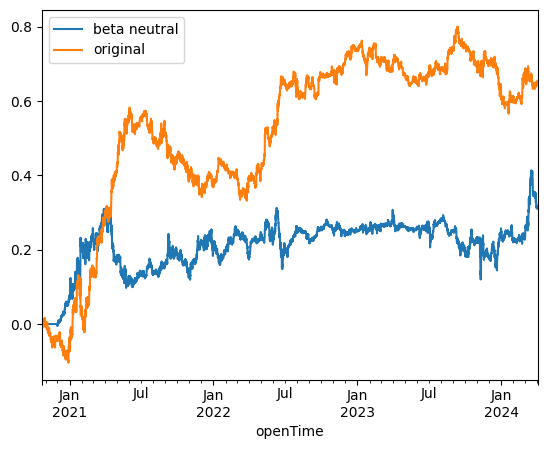

In [ ]:
pnl_beta.cumsum().plot()
pnl.cumsum().plot()

plt.legend(["beta neutral", "original"])
plt.show()

<Axes: title={'center': 'Strategy Beta'}>

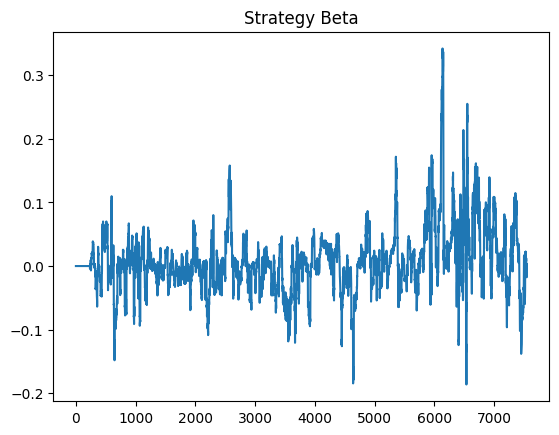

In [ ]:
strategy_beta = []

for t in betas_hat.index:
    beta = betas_hat.loc[t].values
    weights = beta_neut_w.loc[t].values
    strategy_beta.append(np.nansum(beta * weights))

pd.Series(strategy_beta).plot(title="Strategy Beta")